## Lorenz63 System

This notebook evaluates the effectiveness our proposed **KoopSTD** on the well-known Lorenz63 system.

The dataset consists of segments extracted from 500-second simulated trajectories, encompassing five distinct behaviors: line-like, ring-like, Periodic[1-1-2-2], Periodic[1-2], and Chaotic dynamics. For each behavioral type, we include 20 randomly sampled 20-second clips.

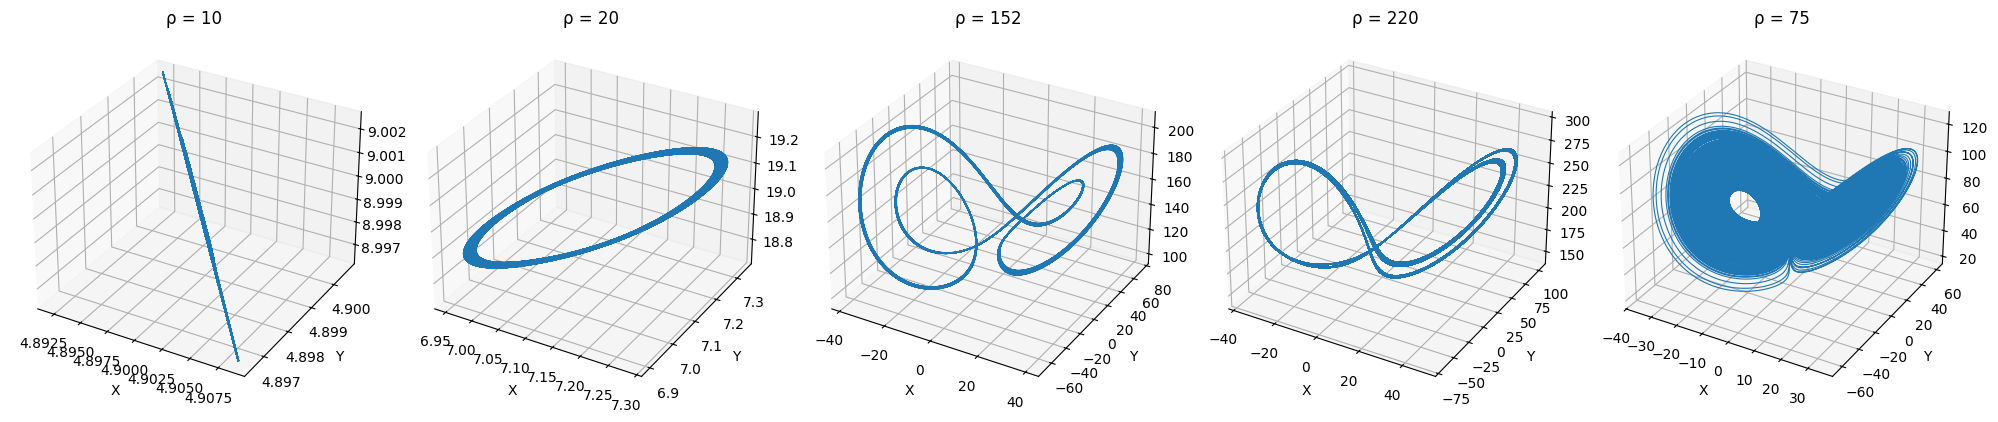

100 (20000, 3)


In [1]:
from koopstd.dynametric import KoopOpMetric
from koopstd.eval import MetricEvaluator
from koopstd.datasets import Lorenz63
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE, MDS
import pandas as pd

lorenz = Lorenz63(rho_values=[10, 20, 152, 220, 75], num_clips=20)
lorenz.visualize_data(time_range=None)

data = lorenz.data
print(len(data), data[0].shape)

In [2]:
# heatmap for distance matrix and scatter plot for MDS projection

def plot_results(distance_matrix, method_name, num_clips):
    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot heatmap
    sns.heatmap(distance_matrix, cmap='viridis', ax=axes[0])
    lorenz_names = ['Line-like', 'Ring-like', 'Periodic-1122', 'Periodic-11', 'Chaotic']
    axes[0].set_title(f'{method_name} Distance Matrix')

    # Set custom tick labels
    tick_positions = [num_clips / 2, num_clips * 3 / 2, num_clips * 5 / 2, num_clips * 7 / 2, num_clips * 9 / 2] 
    axes[0].set_xticks(tick_positions)
    axes[0].set_yticks(tick_positions)
    axes[0].set_xticklabels(lorenz_names, rotation=45, ha='right')
    axes[0].set_yticklabels(lorenz_names, rotation=0)

    # Perform MDS for visualization
    vis = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    embedding = vis.fit_transform(distance_matrix)

    # Create DataFrame for scatter plot
    df = pd.DataFrame()
    df["x"] = embedding[:, 0]
    df["y"] = embedding[:, 1]

    # Add labels for different rho values (5 rho values, 40 clips each)
    rho_labels = []
    rho_values = [10, 20, 152, 220, 75]
    for i,rho in enumerate(rho_values):
        rho_labels.extend([lorenz_names[i]] * num_clips)
    df["System"] = rho_labels

    # Plot scatter with improved styling
    sns.scatterplot(data=df, x="x", y="y", hue="System", ax=axes[1], s=80, alpha=0.8)
    axes[1].set_title(f'MDS Projection of Results by {method_name}')
    axes[1].set_xlabel('MDS Component 1')
    axes[1].set_ylabel('MDS Component 2')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    return plt

### KoopSTD (Ours)

/home/smzhang/miniconda3/envs/koopman/lib/python3.10/site-packages/torch/functional.py:709: UserWarning: A window was not provided. A rectangular window will be applied,which is known to cause spectral leakage. Other windows such as torch.hann_window or torch.hamming_window can are recommended to reduce spectral leakage.To suppress this warning and use a rectangular window, explicitly set `window=torch.ones(n_fft, device=<device>)`. (Triggered internally at /pytorch/aten/src/ATen/native/SpectralOps.cpp:836.)
  return _VF.stft(  # type: ignore[attr-defined]


0.9792429553087325


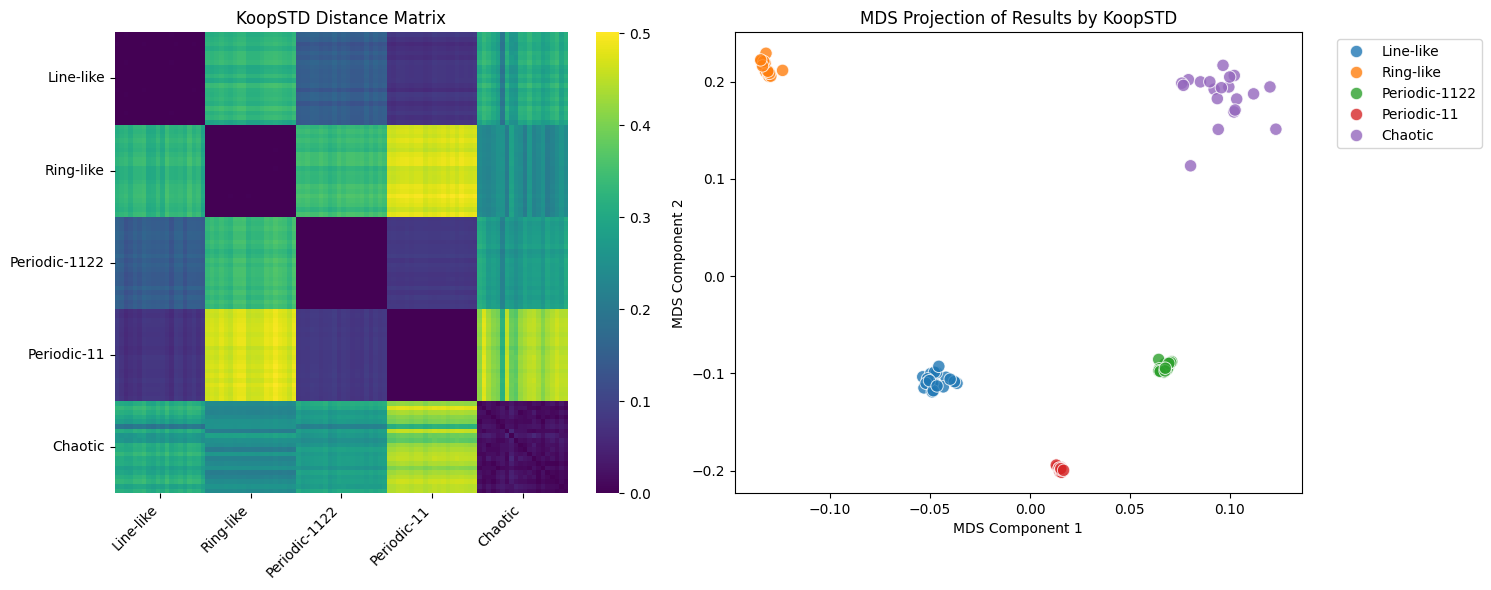

In [3]:
from sklearn.preprocessing import StandardScaler

subsample = 5
data = lorenz.data
ss = StandardScaler()
data = [ss.fit_transform(i) for i in data]
data = [i[::subsample] for i in data]

koopstd_params = {'hop_size': 1, 'win_len': 100, 'rank': 6, 'lamb': 0.1}  # hyper-parameters for KoopSTD(l,s,r)
wasserstein_params = {'p': 1, 'method': 'emd', 'feature_type': 'eig'}  # hyper-parameters for Wasserstein distance

koopstd = KoopOpMetric(X=data, kmd_method='koopstd', kmd_params=koopstd_params, dist='wasserstein', dist_params=wasserstein_params, device='cuda:4')
koopstd_dist_matrix = koopstd.fit_score()

# Evaluate the performance of KoopSTD by Silhouette Coefficient
me = MetricEvaluator(distance_matrix=koopstd_dist_matrix, cluster_sizes=[20, 20, 20, 20, 20])
silhouette = me.evaluate()
print(silhouette)

plt = plot_results(koopstd_dist_matrix, "KoopSTD", 20)
plt.show()

### HAVOK-based DSA (!pip install dsa-metric)

We address the concern raised by the original authors of DSA (Ostrow et al., 2024) regarding the poor silhouette score reported in our paper, which has been discussed since the PR1 exchange last August and was recently revisited in their repo (https://github.com/mitchellostrow/DSA/blob/main/examples/dsa_koopstd_fix.ipynb). We appreciate the authors’ clarification on these implementation details.

Following their clarification, we have updated our implementation accordingly, adopting the official DSA codebase with HAVOK-based DMD under the settings specified in the above notebook (n_delays=70, rank=6). We report results under two comparison modes:

- 1. Wasserstein distance between operator eigenvalue distributions. The dynamical regimes can be perfectly separated.
- 2. Procrustes analysis over vector field. The standard comparing mode for operators presented in Ostrow et al., with substantially higher computational cost (~4 hours on a single A6000 GPU) in this experiment.

/home/smzhang/miniconda3/envs/koopman/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fitting DMDs:   3%|▎         | 3/100 [00:00<00:04, 21.98it/s]

Fitting DMDs: 100%|██████████| 100/100 [00:04<00:00, 21.71it/s]


Pre-computing eigenvalues for Wasserstein distance...


Scoring DMD pairs: 100%|██████████| 4950/4950 [00:03<00:00, 1574.07it/s]


0.9977050804222237


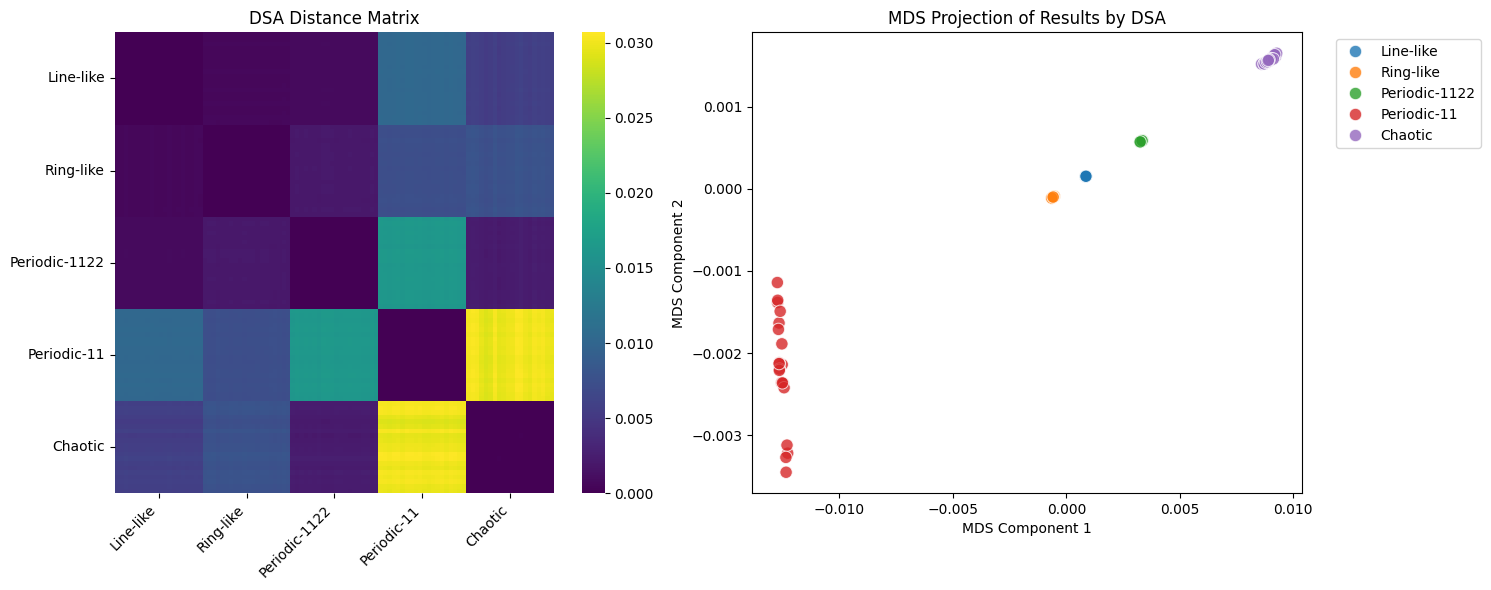

In [4]:
from DSA import DSA

subsample = 10
data = lorenz.data
ss = StandardScaler()
data = [ss.fit_transform(i) for i in data]
data = [i[::subsample] for i in data]

# Wasserstein distance between operator eigenvalue distributions
dsa = DSA(data, n_delays=70, rank=6, verbose=True, score_method="wasserstein", device="cuda:4")
dsa_sim = dsa.fit_score()

me = MetricEvaluator(distance_matrix=dsa_sim, cluster_sizes=[20, 20, 20, 20, 20])
silhouette = me.evaluate()
print(silhouette)

plt = plot_results(dsa_sim, "DSA", 20)
plt.show()

/home/smzhang/miniconda3/envs/koopman/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Scoring DMD pairs: 100%|██████████| 4950/4950 [4:04:38<00:00,  2.97s/it]  


0.8781046036224717


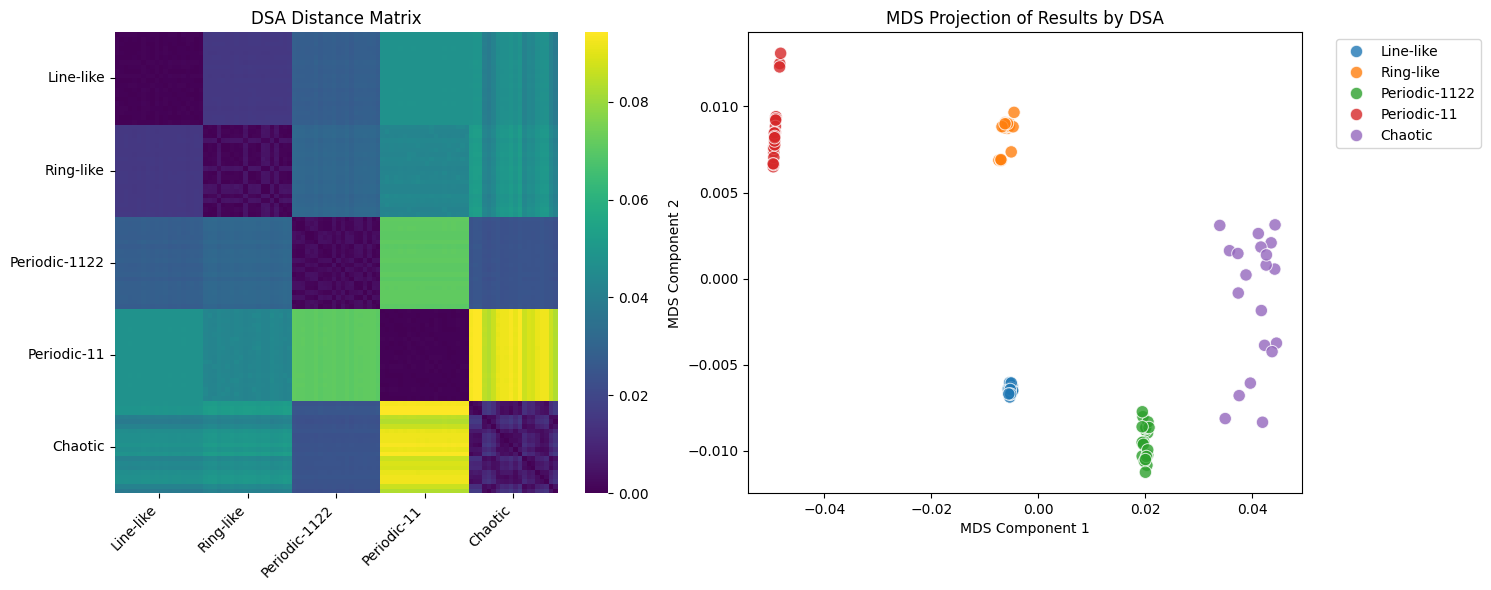

In [ ]:
# Procrustes analysis over vector field, Ostrow et al., NeurIPS 2024
dsa = DSA(data, n_delays=70, rank=6, verbose=True, score_method="angular", device="cuda:4")
dsa_sim = dsa.fit_score()

me = MetricEvaluator(distance_matrix=dsa_sim, cluster_sizes=[20, 20, 20, 20, 20])
silhouette = me.evaluate()
print(silhouette)

plt = plot_results(dsa_sim, "DSA", 20)
plt.show()

While related to DSA, we view methods like KoopSTD within the broader Koopman and DMD framework, where different operator and representation choices naturally give rise to a range of dynamical similarity metrics, each capturing distinct aspects of the underlying dynamics. Moving forward, we are more interested in identifying effective combinations of these components for exploring high-dimensional and open-ended questions, rather than further focusing on this toy dataset.